In [1]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer
import re
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
import spacy
from spacy import tokenizer
from spacy import displacy
!pip install --upgrade gensim
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import TfidfModel,LsiModel
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.0 MB/s eta 0:00:00


In [2]:
plt.rcParams['figure.figsize'] = (12,8)
default_plot_colour = "#00bfbf"

In [3]:
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


Text(0.5, 1.0, 'Count of Fake and Factual Articles')

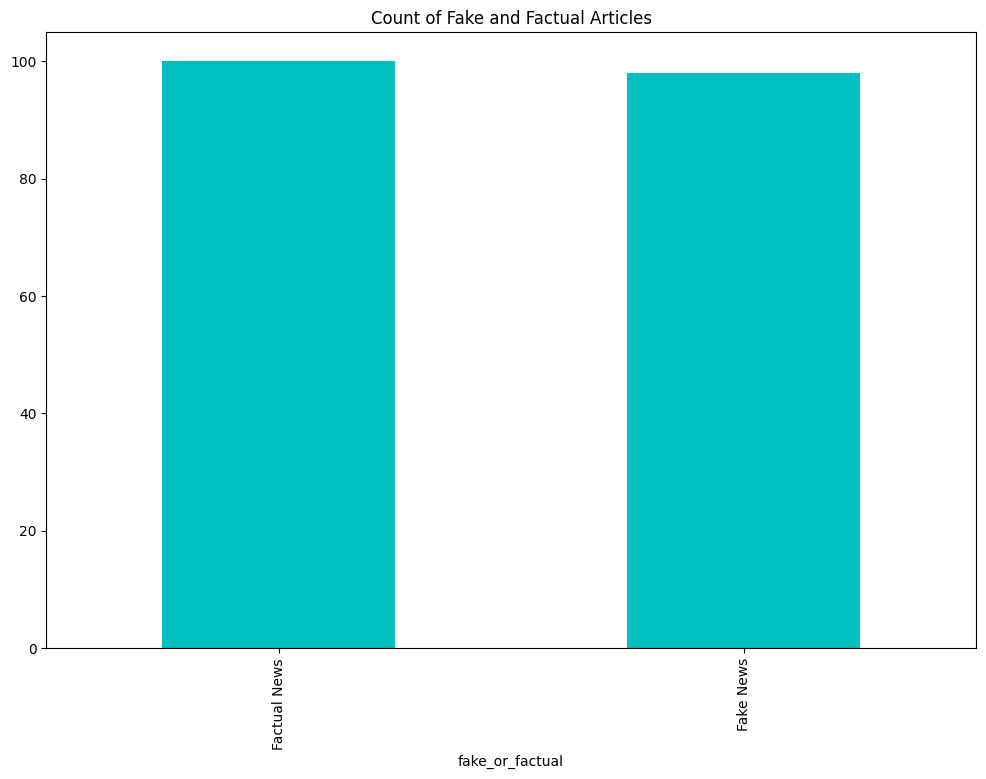

In [4]:
data['fake_or_factual'].value_counts().plot(kind='bar',color=default_plot_colour)
plt.title("Count of Fake and Factual Articles")

POS Taging

In [5]:
nlp = spacy.load("en_core_web_sm")


In [6]:
fake_news = data[data['fake_or_factual']=='Fake News']
factual_news = data[data['fake_or_factual'] == 'Factual News']
fake_news.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
5,Maxine Waters Makes Teens Chant ‘Impeach 45′ a...,Shame on Teen Vogue! Maxine Waters was a guest...,"Dec 10, 2017",Fake News
6,Jay Carney Let It Slip That He Knows Who Obam...,Former White House Press Secretary in the Obam...,"February 10, 2016",Fake News


In [7]:
fake_sdoc = list(nlp.pipe(fake_news['text']))
factual_sdoc = list(nlp.pipe(factual_news['text']))

In [8]:
def extract_pos_tags(doc : spacy.tokens.doc.Doc):
  return [(i.text,i.ent_type_,i.pos_) for i in doc]

fake_tagsdf = []
cols = ["token","ner_tag","pos_tag"]
for token in fake_sdoc:
  tags = extract_pos_tags(token)
  tags = pd.DataFrame(tags)
  tags.columns = cols
  fake_tagsdf.append(tags)

In [9]:
fake_tagsdf = pd.concat(fake_tagsdf)
print(fake_tagsdf)

        token   ner_tag pos_tag
0       There              PRON
1         are              VERB
2         two  CARDINAL     NUM
3       small               ADJ
4    problems              NOUN
..        ...       ...     ...
743         .             PUNCT
744       Via             PROPN
745         :             PUNCT
746    Campus    PERSON   PROPN
747    Reform    PERSON   PROPN

[45744 rows x 3 columns]


In [10]:
fact_tagsdf = []
for token in factual_sdoc:
  tags = extract_pos_tags(token)
  tags = pd.DataFrame(tags)
  tags.columns = cols
  fact_tagsdf.append(tags)
fact_tagsdf = pd.concat(fact_tagsdf)
fact_tagsdf.head()

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT


In [11]:
pos_count_fake = fake_tagsdf.groupby(['token','pos_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
pos_count_fake.head(10)

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [12]:
pos_count_fact = fact_tagsdf.groupby(['token','pos_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
pos_count_fact.head(10)

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [13]:
pos_count_fake.groupby(['pos_tag'])['token'].count().sort_values(ascending=False).head(10)

,token
pos_tag,
NOUN,2586
VERB,1817
PROPN,1672
ADJ,882
ADV,413
NUM,221
PRON,96
ADP,89
AUX,62


In [14]:
pos_count_fake[pos_count_fake.pos_tag == 'NOUN'][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
8011,year,NOUN,44
3138,campaign,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [15]:
pos_count_fact[pos_count_fact.pos_tag == 'NOUN'][:15]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
2497,campaign,NOUN,42


Named Entities Analysis

In [16]:
top_entities_fake = fake_tagsdf[fake_tagsdf.ner_tag != ""].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
top_entities_fake.head(10)

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


In [17]:
top_entities_fact = fact_tagsdf[fact_tagsdf.ner_tag != ""].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
top_entities_fact.head(10)

,token,ner_tag,counts
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
882,House,ORG,67
1997,year,DATE,63
1965,the,GPE,59
1646,United,GPE,59
1532,States,GPE,55


In [18]:
ner_palette = {
    "ORG" : sns.color_palette("Set2").as_hex()[0],
    "GPE" : sns.color_palette("Set2").as_hex()[1],
    "NORP" : sns.color_palette("Set2").as_hex()[2],
    "PERSON" : sns.color_palette("Set2").as_hex()[3],
    "DATE" : sns.color_palette("Set2").as_hex()[4],
    "CARDINAL" : sns.color_palette("Set2").as_hex()[5],
    "PERCENT" : sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most common Entities in Fake News')]

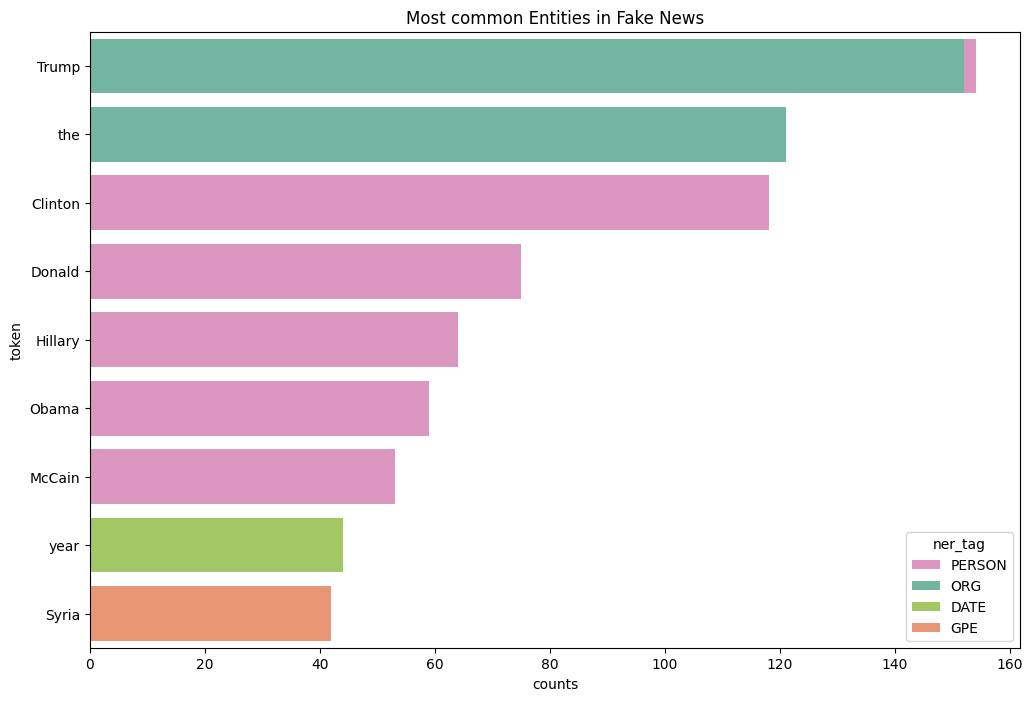

In [19]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient='h',
    dodge = False
).set(title="Most common Entities in Fake News")

[Text(0.5, 1.0, 'Most common Entities in Factual News')]

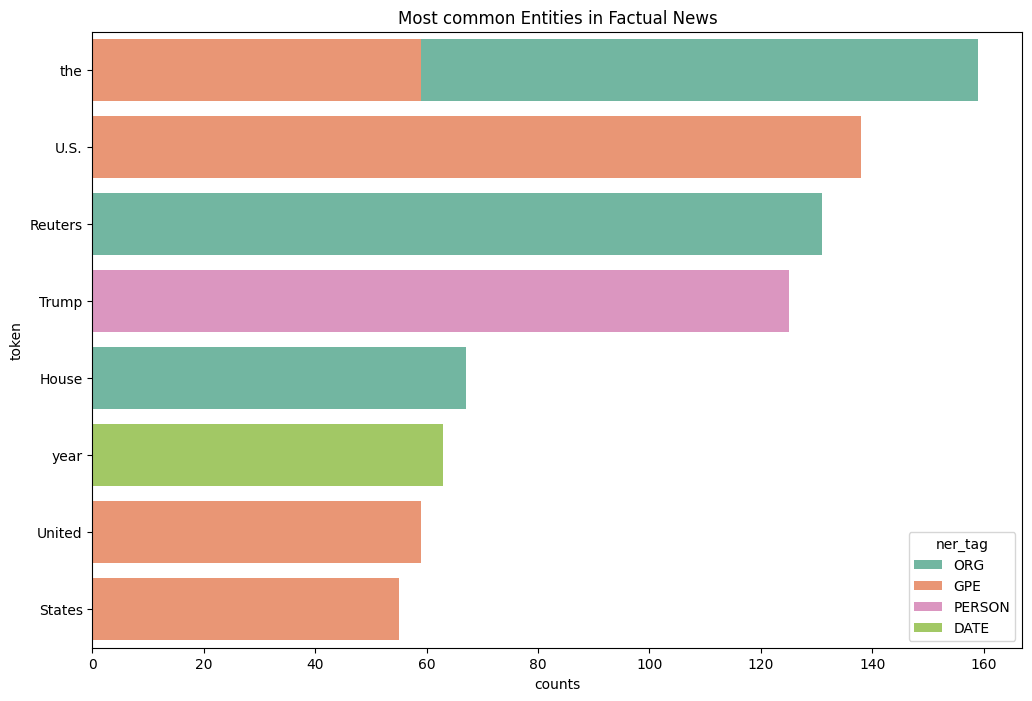

In [20]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[:10],
    orient='h',
    dodge = False
).set(title="Most common Entities in Factual News")

Text Processing

In [21]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [22]:
data['text_clean'] = data.apply(lambda x : re.sub(r"^[^-]*-\s","",x['text']),axis=1)
data.head(3)

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,There are two small problems with your analogy...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,Buried in Trump s bonkers interview with New Y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"Women make up over 50 percent of this country,..."


In [23]:
data['text_clean'] = data['text_clean'].str.lower()
data['text_clean'] = data.apply(lambda x : re.sub(r"([^\w\s])","",x['text_clean']),axis=1)

In [24]:
import nltk
nltk.download('stopwords')
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
data['text_clean'] = data['text_clean'].apply(lambda x : ' '.join(word for word in x.split() if word not in en_stopwords))

In [26]:
nltk.download('punkt_tab')
data['text_clean'] = data['text_clean'].apply(lambda x : word_tokenize(x))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [27]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda tokens : [lemmatizer.lemmatize(token) for token in tokens])
data.head(5)

[nltk_data] Downloading package wordnet to /root/nltk_data...


,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [28]:
tokens_clean = sum(data['text_clean'],[])
unigrams = (pd.Series(nltk.ngrams(tokens_clean,1)).value_counts()).reset_index()[:10]
unigrams

,index,count
0,"(trump,)",580
1,"(said,)",580
2,"(u,)",277
3,"(state,)",275
4,"(president,)",259
5,"(would,)",226
6,"(one,)",160
7,"(clinton,)",141
8,"(year,)",139
9,"(republican,)",137


/tmp/ipython-input-1750/2762744916.py:2: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common unigrams after processing')]

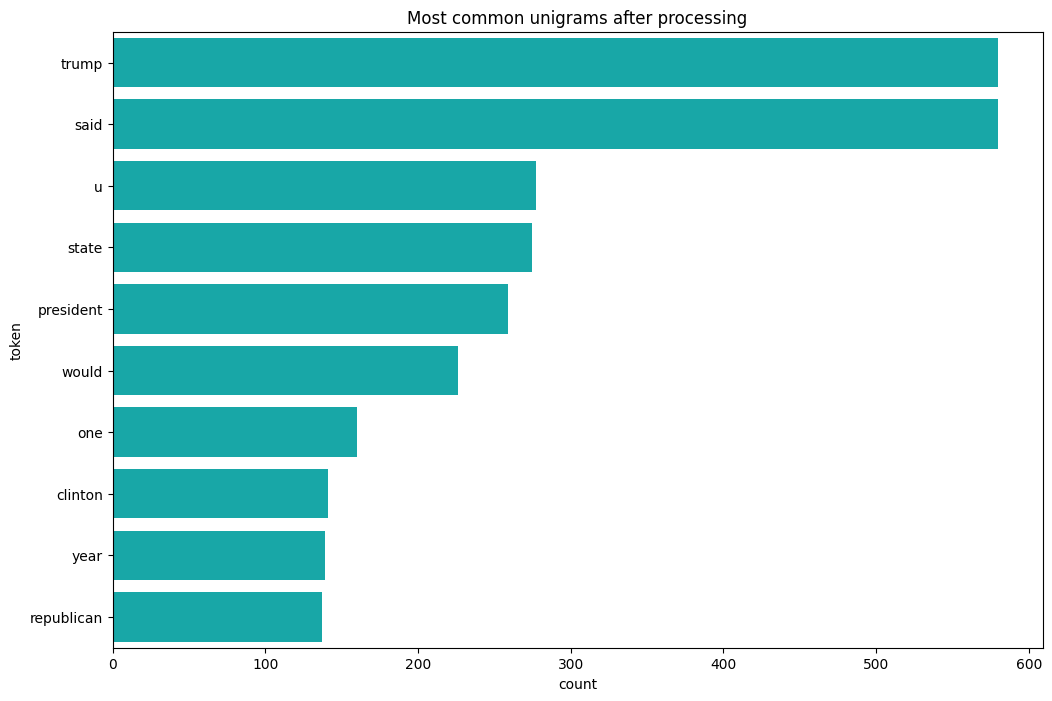

In [29]:
unigrams['token'] = unigrams['index'].apply(lambda x : x[0])
sns.barplot(
    x = 'count',
    y = 'token',
    data = unigrams,
    palette = [default_plot_colour],
    hue= 'token',
    orient='h',
    legend = False
).set(title="Most common unigrams after processing")

In [30]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean,2)).value_counts()).reset_index()[:10]
bigrams

,index,count
0,"(donald, trump)",113
1,"(united, state)",84
2,"(white, house)",74
3,"(president, donald)",47
4,"(hillary, clinton)",39
5,"(new, york)",33
6,"(supreme, court)",30
7,"(image, via)",29
8,"(official, said)",26
9,"(trump, administration)",26


/tmp/ipython-input-1750/4285420235.py:2: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most Common Bigrams after processing')]

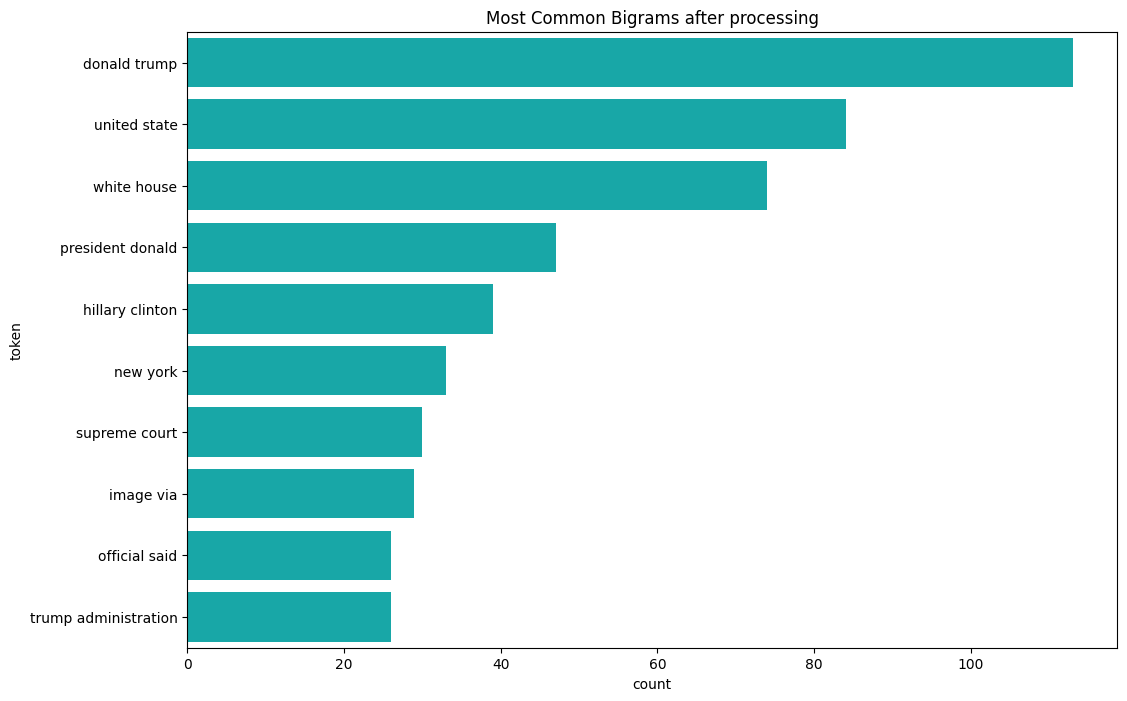

In [31]:
bigrams['token'] = bigrams['index'].apply(lambda x : ' '.join(x))
sns.barplot(
    x = 'count',
    y = 'token',
    data = bigrams,
    palette = [default_plot_colour],
    hue= 'index',
    orient='h',
    legend = False
).set(title='Most Common Bigrams after processing')

Sentiment Analysis

In [32]:
nltk.download('vader_lexicon')
vader_sentiment = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [33]:
data['sentiment_score'] = data['text'].apply(lambda x : vader_sentiment.polarity_scores(x)['compound'])
data.head()

,title,text,date,fake_or_factual,text_clean,sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.7973
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9886
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [34]:
bins = [-1,-0.1,0.1,1]
names = ['negative','neutral','positive']
data['vader_labels'] = (pd.cut(data['sentiment_score'],bins,labels=names))

<Axes: xlabel='vader_labels'>

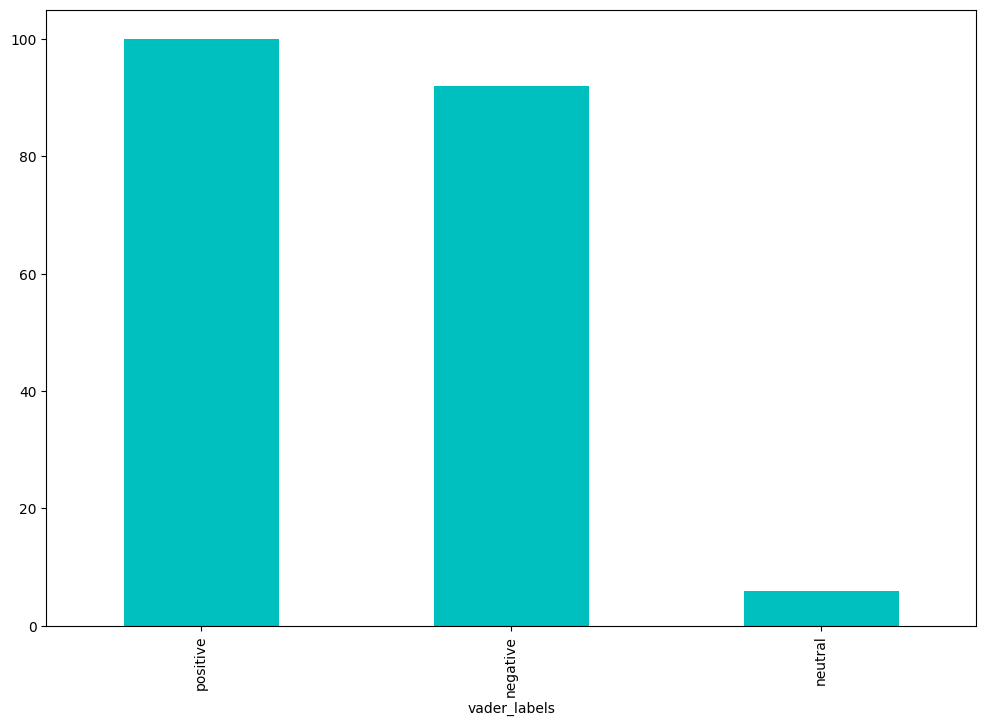

In [35]:
data['vader_labels'].value_counts().plot.bar(color=default_plot_colour)

/tmp/ipython-input-1750/3942464655.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment Analysis')]

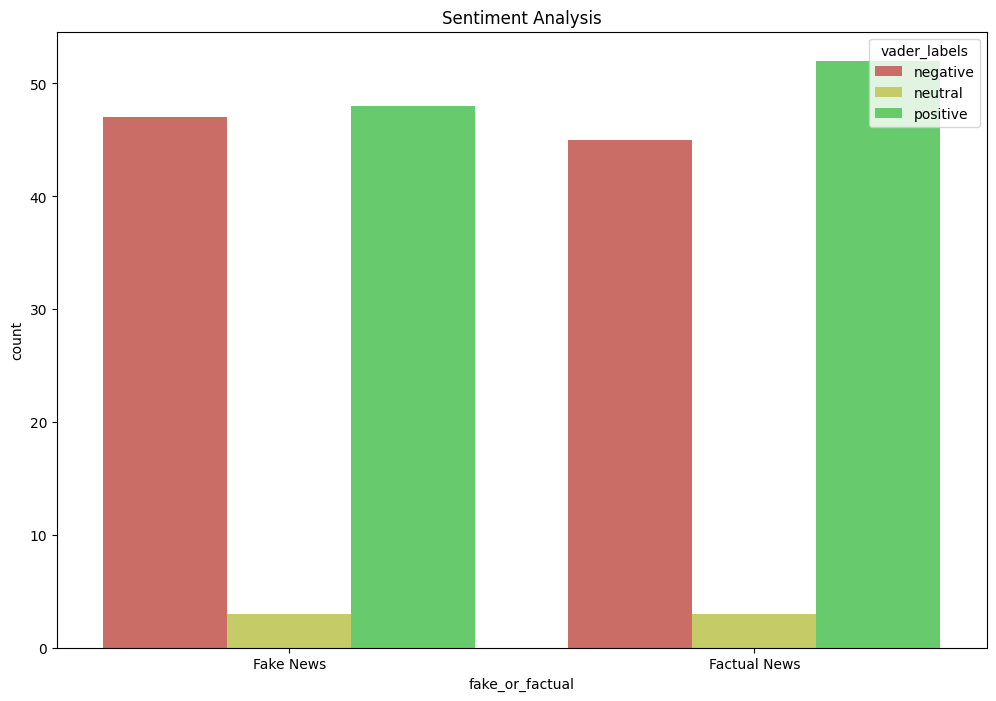

In [36]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_labels',
    data = data,
    palette = sns.color_palette('hls')
).set(title='Sentiment Analysis')

Topic Modelling

In [37]:
fake_news_text = data[data['fake_or_factual']=='Fake News']['text_clean'].reset_index(drop=True)

In [38]:
dict_fake = corpora.Dictionary(fake_news_text)

In [39]:
doc_term_fake = [dict_fake.doc2bow(text) for text in fake_news_text]

In [40]:
coherence_scores = []
models = []
min_topics = 2
max_topics = 11
for i in range(min_topics,max_topics+1):
  model = gensim.models.LdaModel(doc_term_fake,num_topics=i,id2word=dict_fake)
  models.append(model)
  coherence_model= CoherenceModel(model=model,texts=fake_news_text,dictionary=dict_fake,coherence='c_v')
  coherence_scores.append(coherence_model.get_coherence())

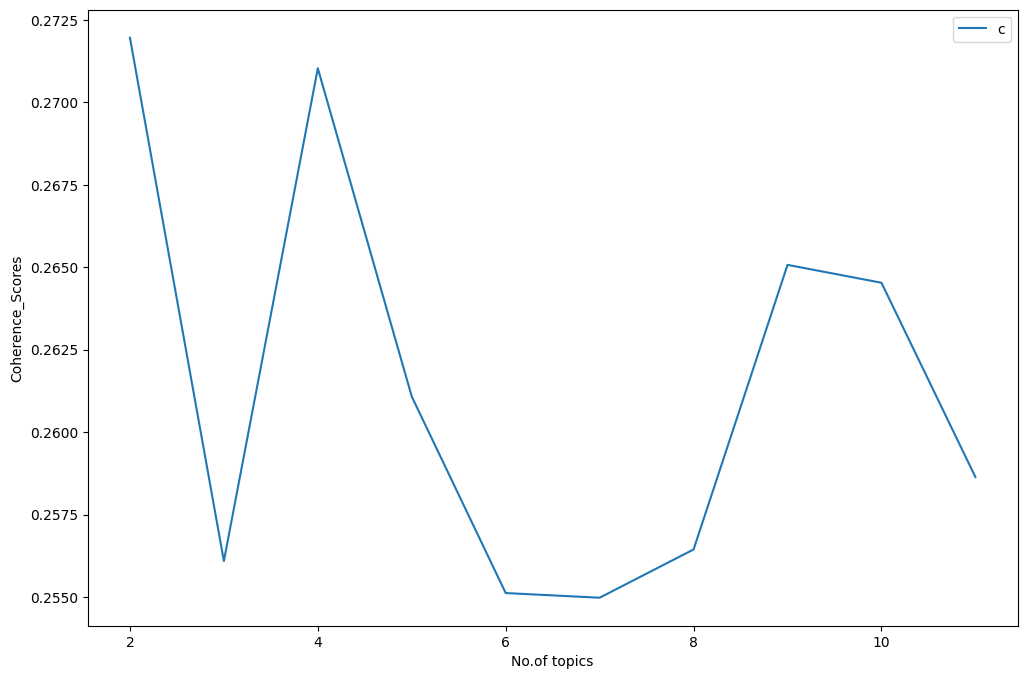

In [41]:
plt.plot(range(min_topics,max_topics+1),coherence_scores)
plt.xlabel('No.of topics')
plt.ylabel('Coherence_Scores')
plt.legend('coherence_scores',loc='best')
plt.show()


In [42]:
num_topics_lda = 7
lda_model = gensim.models.LdaModel(corpus=doc_term_fake,num_topics=num_topics_lda,id2word=dict_fake)

In [43]:
lda_model.print_topics(num_words=10)

[(0,
  '0.010*"trump" + 0.006*"president" + 0.005*"obama" + 0.005*"said" + 0.005*"clinton" + 0.004*"would" + 0.004*"state" + 0.004*"time" + 0.004*"republican" + 0.004*"donald"'),
 (1,
  '0.008*"trump" + 0.004*"people" + 0.004*"said" + 0.004*"even" + 0.003*"state" + 0.003*"republican" + 0.003*"donald" + 0.003*"one" + 0.003*"time" + 0.003*"president"'),
 (2,
  '0.007*"trump" + 0.004*"would" + 0.004*"said" + 0.004*"woman" + 0.003*"president" + 0.003*"clinton" + 0.003*"state" + 0.003*"donald" + 0.002*"u" + 0.002*"candidate"'),
 (3,
  '0.008*"trump" + 0.004*"would" + 0.004*"one" + 0.003*"president" + 0.003*"u" + 0.003*"year" + 0.002*"clinton" + 0.002*"american" + 0.002*"woman" + 0.002*"state"'),
 (4,
  '0.011*"trump" + 0.005*"clinton" + 0.005*"state" + 0.005*"president" + 0.004*"would" + 0.003*"said" + 0.003*"u" + 0.003*"one" + 0.003*"woman" + 0.003*"mccain"'),
 (5,
  '0.013*"trump" + 0.007*"said" + 0.006*"clinton" + 0.006*"president" + 0.005*"u" + 0.004*"state" + 0.004*"time" + 0.003*"one"

Most of the topics obtained from LDA Model are very similar, so we use LSA

In [44]:
def tfidf_corpus(doc_term_matrix):
  tfidf = TfidfModel(corpus=doc_term_matrix,normalize=True)
  corpus_tfidf = tfidf[doc_term_matrix]
  return corpus_tfidf

In [45]:
def get_coherence_scores(corpus,dictionary,text,min_topics,max_topics):
  coherence_values = []
  models = []
  for i in range(min_topics,max_topics+1):
    model = LsiModel(corpus,id2word=dictionary,num_topics=i)
    models.append(model)
    coherence_model = CoherenceModel(model,texts=text,dictionary=dictionary,coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

  plt.plot(range(min_topics,max_topics+1),coherence_values)
  plt.xlabel('No.of topics')
  plt.ylabel('Coherence Values')
  plt.legend('coherence_values',loc="best")
  plt.show()

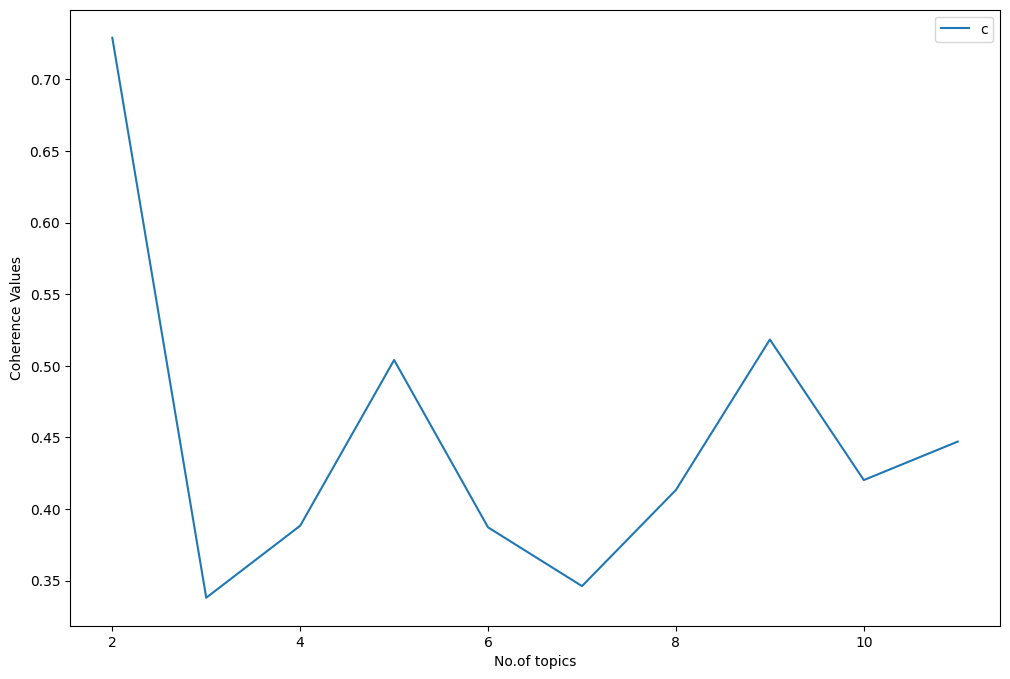

In [46]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)
get_coherence_scores(corpus=corpus_tfidf_fake,dictionary=dict_fake,text=fake_news_text,min_topics=2,max_topics=11)

In [47]:
lsa_model = LsiModel(corpus=corpus_tfidf_fake,num_topics=7,id2word=dict_fake)
lsa_model.print_topics(num_words=10)

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.077*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '-0.325*"boiler" + -0.284*"acr" + -0.244*"room" + -0.240*"pm" + -0.186*"broadcast" + -0.180*"radio" + -0.142*"tune" + -0.142*"animal" + -0.134*"jay" + -0.132*"episode"'),
 (2,
  '0.623*"flynn" + 0.182*"immunity" + 0.122*"nana" + 0.116*"mr" + 0.110*"30" + 0.108*"march" + 0.102*"russian" + 0.100*"source" + -0.095*"school" + 0.092*"adviser"'),
 (3,
  '-0.217*"clinton" + 0.186*"school" + 0.176*"student" + -0.141*"hillary" + 0.121*"county" + 0.121*"flynn" + -0.110*"sander" + -0.098*"debate" + -0.097*"woman" + -0.091*"nominee"'),
 (4,
  '-0.200*"email" + 0.194*"trump" + -0.168*"dnc" + 0.142*"flynn" + -0.126*"clinton" + 0.112*"cruz" + -0.111*"department" + -0.110*"rich" + -0.102*"wikileaks" + -0.099*"sander"'),
 (5,
  '-0.276*"student" + -0.160*"conference" + -0.160*"school" + -0.137*"trump" + 0.125*"mc

Creating a custom classifier

In [48]:
data.head()

,title,text,date,fake_or_factual,text_clean,sentiment_score,vader_labels
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.7973,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9886,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [49]:
X = [','.join(map(str,text)) for text in data['text_clean']]
y = data['fake_or_factual']

In [50]:
countvec = CountVectorizer()

In [51]:
countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(),columns=countvec.get_feature_names_out())
bag_of_words.head()

,01,03,05,08441,10,100,1000,10000,1000000000000000,1002,...,zimbabwean,zimdars,zimmerman,zina,zionism,zoe,zone,zoom,zouka,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
X_train,X_test,y_train,y_test = train_test_split(bag_of_words,y,test_size=0.3)

In [53]:
lr = LogisticRegression(random_state=0).fit(X_train,y_train)

In [54]:
y_pred_lr = lr.predict(X_test)

In [55]:
accuracy_score(y_pred_lr,y_test)

0.8333333333333334

In [56]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.94      0.78      0.85        37
   Fake News       0.72      0.91      0.81        23

    accuracy                           0.83        60
   macro avg       0.83      0.85      0.83        60
weighted avg       0.85      0.83      0.84        60



In [57]:
svm = SGDClassifier().fit(X_train,y_train)

In [58]:
y_pred_svm = svm.predict(X_test)

In [59]:
accuracy_score(y_pred_svm,y_test)

0.85

In [60]:
print(classification_report(y_pred_svm,y_test))

              precision    recall  f1-score   support

Factual News       0.84      0.91      0.87        34
   Fake News       0.87      0.77      0.82        26

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60

